In [24]:
import pandas as pd
import numpy as np

In [25]:
data = pd.read_csv("E:/LPU/SEM 5/CSD 302_MACHINE LEARNING-I/ETE/taxi_trip_pricing.csv")

In [26]:
data.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [27]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    str    
 2   Day_of_Week            950 non-null    str    
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    str    
 5   Weather                950 non-null    str    
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), str(4)
memory usage: 108.5 KB


In [28]:
data.size

11000

In [29]:
data.shape

(1000, 11)

In [30]:
data.columns.to_list()

['Trip_Distance_km',
 'Time_of_Day',
 'Day_of_Week',
 'Passenger_Count',
 'Traffic_Conditions',
 'Weather',
 'Base_Fare',
 'Per_Km_Rate',
 'Per_Minute_Rate',
 'Trip_Duration_Minutes',
 'Trip_Price']

In [31]:
data.nunique()

Trip_Distance_km         867
Time_of_Day                4
Day_of_Week                2
Passenger_Count            4
Traffic_Conditions         3
Weather                    3
Base_Fare                290
Per_Km_Rate              150
Per_Minute_Rate           41
Trip_Duration_Minutes    917
Trip_Price               951
dtype: int64

In [32]:
data.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [33]:
data.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [34]:
data.isnull()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,True,False,False
997,False,False,False,False,False,False,False,False,True,False,False
998,False,False,False,False,False,False,False,False,False,False,False


In [35]:
data.dropna(inplace = True)

In [36]:
data.isnull().sum()

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64

In [37]:
data["Time_of_Day"].value_counts

<bound method IndexOpsMixin.value_counts of 0        Morning
2        Evening
5      Afternoon
12         Night
14       Evening
         ...    
990      Evening
992    Afternoon
994      Evening
995    Afternoon
998      Morning
Name: Time_of_Day, Length: 562, dtype: str>

<Axes: title={'center': ' Time of Day'}, xlabel='Time_of_Day'>

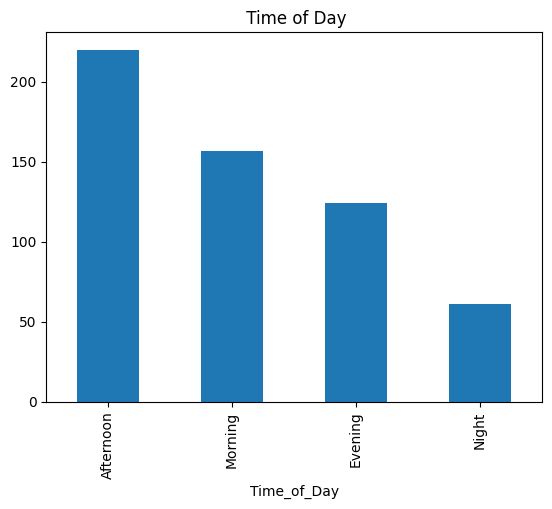

In [38]:
data["Time_of_Day"].value_counts().plot(kind="bar", title=" Time of Day")

In [39]:
data["Day_of_Week"].value_counts

<bound method IndexOpsMixin.value_counts of 0      Weekday
2      Weekend
5      Weekend
12     Weekend
14     Weekday
        ...   
990    Weekday
992    Weekday
994    Weekday
995    Weekend
998    Weekday
Name: Day_of_Week, Length: 562, dtype: str>

<Axes: title={'center': 'Day of Week'}, xlabel='Day_of_Week'>

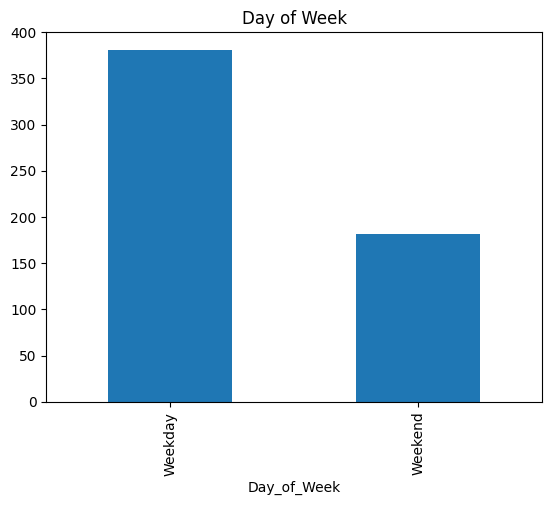

In [40]:
data["Day_of_Week"].value_counts().plot(kind="bar", title="Day of Week")

In [41]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

C:\Users\adity\AppData\Local\Temp\ipykernel_16188\237923547.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(include='object').columns:


In [42]:
X = data.drop("Trip_Price", axis=1)
y = data["Trip_Price"]

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [44]:
from sklearn.linear_model import LinearRegression
mod = LinearRegression()
mod.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [45]:
y_pred = mod.predict(X_test)

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 11.253114722986345
MSE: 316.1339293804068
R2: 0.8418341033484653
